# LightGBM baseline on quarterly splits

Goal: Starting with train data covering 2003-2006 and then incrementing data in quarters, we provide recommendations for the next quarter. 

To run before running this: `scripts/download_data.py` and `scripts/make_splits.py`

The model is trained on:

- User features: prior review count, mean rating, 5-star rate, and days since last review.
- Recipe features: binary indicators for recipe tags.
- Positive examples: available, previously unseen recipes that receive a 5-star interaction during the quarter.
- Negative examples: a small random sample of other recipes that were available and unseen at the quarter start. Helps tackle the issue of otherwise treating unrated examples as negative interactions, as they are not. 

Per quarter, we create positive and negative examples augmented with the user and recipe features, then concatenate all rows across all quarters and fit a binary LightGBM model.

At inference, LightGBM scores every available recipe the user has not previously reviewed and sorts by predicted score. Recipe popularity is a fallback for users with fewer than three prior reviews.

In [1]:
# Optional if you have trouble running the environment.
import sys
sys.path.insert(0, "../src")

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import time

from remy.splits import RollingSplits, SPLIT_DIR
from remy.model.lightgbm_new import LightGBMNew
from remy.evaluate import evaluate_quarter

In [3]:
splits = RollingSplits()
split = "val"  # Use "test" only after choosing and fixing model settings.

n_eval_quarters = None  # Set to a small integer for a quick debugging run.
model_kwargs = dict(
    negatives_per_positive=10, # can be tuned
    num_boost_round=200, # can be tuned
    n_candidates=1000 # can be tuned
)

splits.windows.groupby("split", sort=False)[
    ["outcome_reviews", "positive_reviews", "positive_users"]
].sum().rename(columns={"positive_users": "positive_user_quarters"})

,outcome_reviews,positive_reviews,positive_user_quarters
split,,,
train,138126,106422,19880
val,377717,279537,61814
test,134059,100846,29079


## Fit and evaluate the LightGBM model

For each of the 16 evaluation quarters from 2007-2010, provide a fresh model with:
- quarter history: all interactions before the validation start date
- recipes: all recipes from interactions before the validation start date
- training quarters: list of all historical splits, used to create features and labels for training

Then, evaluate the model on that quarter's validation data by generating a full user-specific ranking of available unseen recipes. Users with no positive rating that quarter receive no ranking score. Finally, report average numbers for each metric. 

In [4]:
rows = []
eval_quarters = splits.evaluation_quarters(split)
eval_quarters = eval_quarters[:n_eval_quarters] if n_eval_quarters is not None else eval_quarters

total_start = time.perf_counter()

for quarter in eval_quarters:
    quarter_start = time.perf_counter()

    model = LightGBMNew(**model_kwargs)
    model.fit(
        quarter.history,
        recipes=quarter.recipes,
        training_quarters=splits.training_quarters(quarter.start),
    )
    # Current outcomes are used only for scoring, after the fit.
    recs = model.recommend_many(quarter.outcomes.loc[quarter.outcomes["rating"] == 5, "user_id"].unique())
    rows.append(evaluate_quarter(quarter, model.ranking_, model.seen_, recs))

    quarter_time = time.perf_counter() - quarter_start
    total_time = time.perf_counter() - total_start
    print(
        f"Finished evaluation for quarter {quarter.start.date()} "
        f"in {quarter_time / 60:.2f} min "
        f"(total: {total_time / 60:.2f} min)"
    )

results = pd.DataFrame(rows)
results.to_csv(SPLIT_DIR / f"lightgbm_{split}.csv", index=False)
results[["NDCG", "HR@10", "HR@100", "Recall@10", "Recall@100", "candidate_recall"]].mean().to_frame("Mean across quarters").round(4)

Finished evaluation for quarter 2007-01-01 in 0.58 min (total: 0.58 min)
Finished evaluation for quarter 2007-04-01 in 0.64 min (total: 1.21 min)
Finished evaluation for quarter 2007-07-01 in 0.72 min (total: 1.94 min)
Finished evaluation for quarter 2007-10-01 in 0.77 min (total: 2.70 min)
Finished evaluation for quarter 2008-01-01 in 0.87 min (total: 3.58 min)
Finished evaluation for quarter 2008-04-01 in 0.98 min (total: 4.55 min)
Finished evaluation for quarter 2008-07-01 in 1.02 min (total: 5.57 min)
Finished evaluation for quarter 2008-10-01 in 1.09 min (total: 6.67 min)
Finished evaluation for quarter 2009-01-01 in 1.23 min (total: 7.90 min)
Finished evaluation for quarter 2009-04-01 in 1.29 min (total: 9.19 min)
Finished evaluation for quarter 2009-07-01 in 1.25 min (total: 10.44 min)
Finished evaluation for quarter 2009-10-01 in 1.34 min (total: 11.78 min)
Finished evaluation for quarter 2010-01-01 in 1.46 min (total: 13.24 min)
Finished evaluation for quarter 2010-04-01 in 1.

,Mean across quarters
NDCG,0.1215
HR@10,0.0292
HR@100,0.1346
Recall@10,0.0115
Recall@100,0.0558
candidate_recall,0.1538


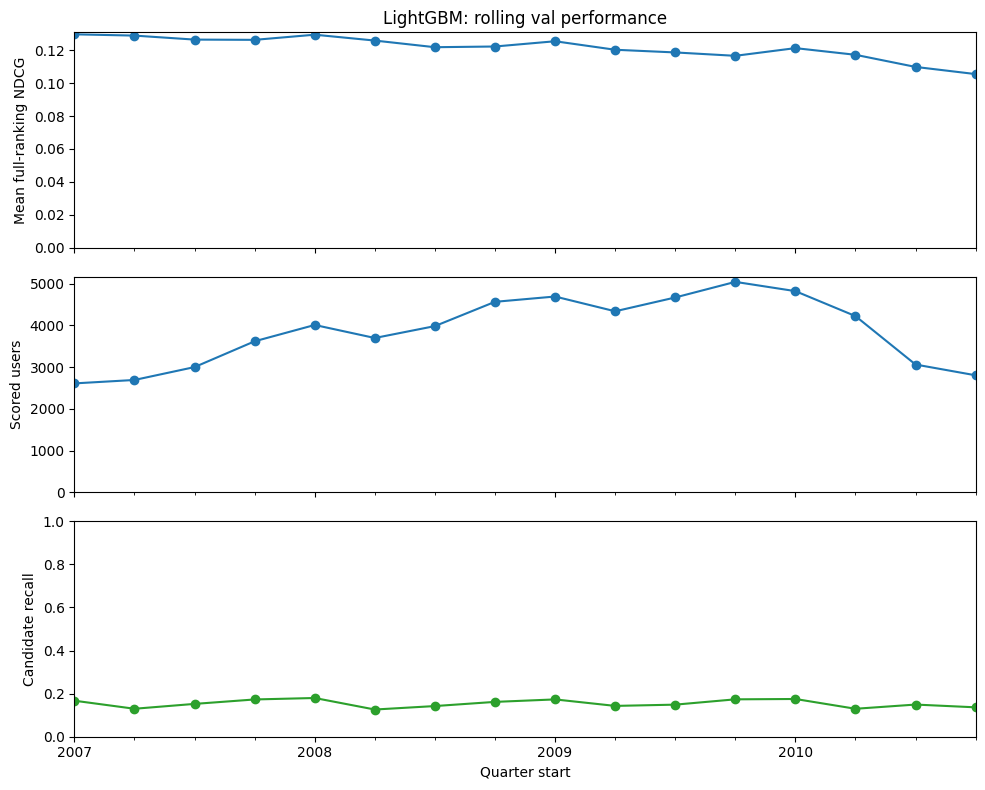

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
results.plot(x="start", y="NDCG", marker="o", legend=False, ax=axes[0])
axes[0].set(title=f"LightGBM: rolling {split} performance", ylabel="Mean full-ranking NDCG")
axes[0].set_ylim(bottom=0)
results.plot(x="start", y="scored_users", marker="o", legend=False, ax=axes[1])
axes[1].set(ylabel="Scored users")
axes[1].set_ylim(bottom=0)
results.plot(x="start", y="candidate_recall", marker="o", legend=False, color="tab:green", ax=axes[2])
axes[2].set(ylabel="Candidate recall", xlabel="Quarter start")
axes[2].set_ylim(0, 1)
fig.tight_layout()
plt.show()

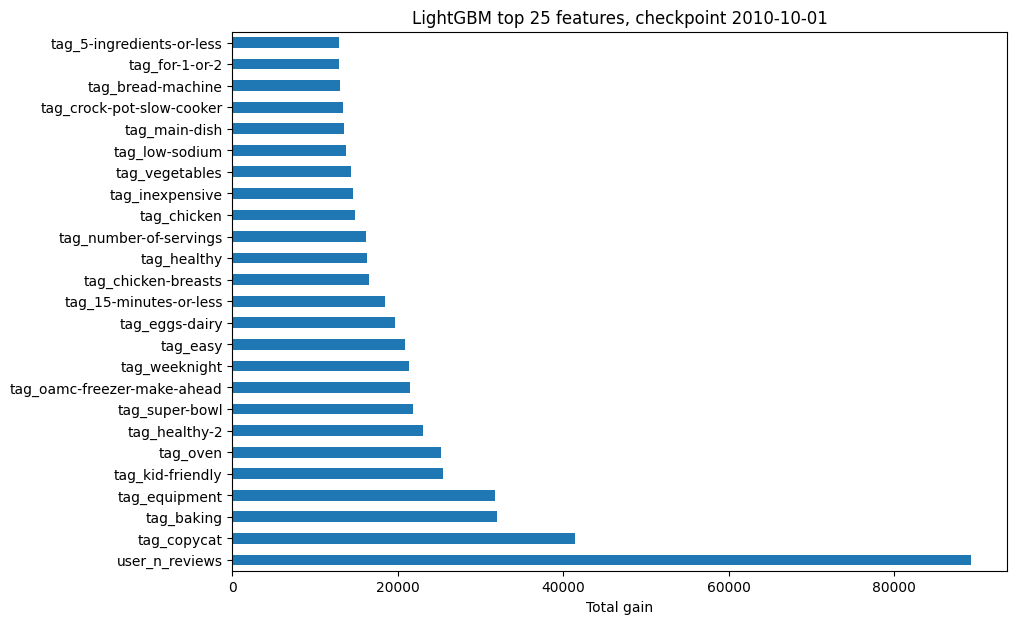

In [6]:
importance = pd.Series(model.model_.feature_importance("gain"), index=model.feature_names_).sort_values(ascending=False).head(25)
ax = importance.plot.barh(figsize=(10, 7), legend=False)
ax.set(title=f"LightGBM top 25 features, checkpoint {quarter.start.date()}", xlabel="Total gain")
fig.tight_layout()
plt.show()